In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

In [22]:
# =============================
# MDP ENVIRONMENT
# =============================
class MazeEnv:
    """
    A grid-based MDP environment.
    Actions: 0=North, 1=East, 2=South, 3=West
    At each step the agent may slip 90 degrees with probability slip_prob.
    """

    MOVES = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    def __init__(self, rows=4, cols=4, goal_states=None,
                 step_cost=-1.0, slip_prob=0.0):
        self.rows        = rows
        self.cols        = cols
        self.nS          = rows * cols
        self.nA          = 4
        self.goals       = set(goal_states or [])
        self.step_cost   = step_cost
        self.slip_prob   = slip_prob
        self.P           = self._make_transitions()

    def state_to_rc(self, s):      return divmod(s, self.cols)
    def rc_to_state(self, r, c):   return r * self.cols + c

    def display(self):
        for r in range(self.rows):
            row = []
            for c in range(self.cols):
                s = self.rc_to_state(r, c)
                row.append('G' if s in self.goals else '.')
            print(' '.join(row))
        print()

    def _make_transitions(self):
        T = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}

        for s in range(self.nS):
            if s in self.goals:
                for a in range(self.nA):
                    T[s][a] = [(1.0, s, 0.0, True)]
                continue

            r, c = self.state_to_rc(s)
            for a in range(self.nA):
                if self.slip_prob == 0.0:
                    action_probs = [(a, 1.0)]
                else:
                    action_probs = [
                        (a,            1.0 - self.slip_prob),
                        ((a - 1) % 4,  self.slip_prob / 2.0),
                        ((a + 1) % 4,  self.slip_prob / 2.0),
                    ]

                merged = {}
                for act, prob in action_probs:
                    dr, dc = self.MOVES[act]
                    nr = np.clip(r + dr, 0, self.rows - 1)
                    nc = np.clip(c + dc, 0, self.cols - 1)
                    ns   = self.rc_to_state(nr, nc)
                    done = ns in self.goals
                    merged[(ns, done)] = merged.get((ns, done), 0.0) + prob

                T[s][a] = [(p, ns, self.step_cost, done)
                           for (ns, done), p in merged.items()]
        return T

In [23]:
# =============================
# BELLMAN HELPERS
# =============================
def compute_q(P, V, s, a, gamma):
    """Q(s, a) under current value estimate V."""
    return sum(
        p * (r + gamma * (0.0 if done else V[ns]))
        for p, ns, r, done in P[s][a]
    )


def bellman_backup(P, V, nS, nA, gamma):
    """One synchronous Bellman optimality backup. Returns new V."""
    new_V = np.zeros(nS)
    for s in range(nS):
        new_V[s] = max(compute_q(P, V, s, a, gamma) for a in range(nA))
    return new_V


def greedy_policy(P, V, nS, nA, gamma):
    """Extract deterministic greedy policy from V."""
    pi = np.zeros((nS, nA))
    for s in range(nS):
        best_a = max(range(nA), key=lambda a: compute_q(P, V, s, a, gamma))
        pi[s, best_a] = 1.0
    return pi

In [24]:
# =============================
# POLICY EVALUATION
# =============================
def eval_policy(P, pi, nS, gamma=0.9, n_sweeps=5):
    """Synchronous policy evaluation for a fixed number of sweeps."""
    V = np.zeros(nS)
    for _ in range(n_sweeps):
        V_new = np.zeros(nS)
        for s in range(nS):
            for a in range(pi.shape[1]):
                V_new[s] += pi[s, a] * compute_q(P, V, s, a, gamma)
        V = V_new
    return V

In [25]:
# =============================
# POLICY ITERATION
# =============================
def run_policy_iteration(P, nS, nA, gamma=0.9, n_sweeps=5):
    """
    Policy Iteration.
    Returns: (policy, V, policy_history, value_history,
               deltas, times, n_iters, total_time)
    """
    pi = np.ones((nS, nA)) / nA      # uniform start
    V_hist, pi_hist, deltas, times = [], [], [], []
    t_start = time.perf_counter()

    while True:
        t0 = time.perf_counter()

        V      = eval_policy(P, pi, nS, gamma, n_sweeps)
        pi_new = greedy_policy(P, V, nS, nA, gamma)

        V_hist.append(V.copy())
        pi_hist.append(pi_new.copy())
        deltas.append(float(np.max(np.abs(pi_new - pi))))
        times.append(time.perf_counter() - t0)

        # Compare chosen actions (robust to float ties)
        if np.array_equal(np.argmax(pi_new, axis=1), np.argmax(pi, axis=1)):
            break
        pi = pi_new

    total = time.perf_counter() - t_start
    return pi_new, V, pi_hist, V_hist, deltas, times, len(deltas), total

In [26]:
# =============================
# VALUE ITERATION
# =============================
def run_value_iteration(P, nS, nA, gamma=0.9, tol=5e-2):
    """
    Value Iteration.
    Returns: (policy, V, value_history, deltas, times, n_iters, total_time)
    """
    V = np.zeros(nS)
    V_hist, deltas, times = [], [], []
    t_start = time.perf_counter()

    while True:
        t0    = time.perf_counter()
        V_new = bellman_backup(P, V, nS, nA, gamma)

        delta = float(np.max(np.abs(V_new - V)))
        V     = V_new

        V_hist.append(V.copy())
        deltas.append(delta)
        times.append(time.perf_counter() - t0)

        if delta < tol:
            break

    pi    = greedy_policy(P, V, nS, nA, gamma)
    total = time.perf_counter() - t_start
    return pi, V, V_hist, deltas, times, len(deltas), total

In [ ]:
# =============================
# VISUALIZATION
# =============================
def show_value_snapshots(V_history, rows, cols, prefix='V'):
    n    = len(V_history)
    ncol = min(6, n)
    nrow = math.ceil(n / ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
    axes = np.array(axes).flatten()
    for i, V in enumerate(V_history):
        grid = V.reshape((rows, cols))
        axes[i].imshow(grid, origin='upper', cmap='coolwarm')
        axes[i].set_title(f'{prefix} {i}')
        for (x, y), v in np.ndenumerate(grid):
            axes[i].text(y, x, f'{v:.2f}', ha='center', va='center', fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout(); plt.show()


def show_policy_arrows(policy_history, rows, cols, prefix='pi'):
    # (col-delta, row-delta) for quiver: N/E/S/W
    _arrow = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}
    n    = len(policy_history)
    ncol = min(6, n)
    nrow = math.ceil(n / ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
    axes = np.array(axes).flatten()
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    for i, pi in enumerate(policy_history):
        U = np.zeros((rows, cols))
        W = np.zeros((rows, cols))
        for s in range(rows * cols):
            r, c = divmod(s, cols)
            dx, dy = _arrow[np.argmax(pi[s])]
            U[r, c], W[r, c] = dx, dy
        axes[i].quiver(X, Y, U, -W)
        axes[i].invert_yaxis()
        axes[i].set_title(f'{prefix} {i}')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout(); plt.show()


def show_convergence_summary(title, pi_res, vi_res):
    _, _, _, _, d_pi, t_pi, _, _ = pi_res
    _, _, _,    d_vi, t_vi, _, _ = vi_res

    # --------- DELTA PLOT ---------
    plt.figure(figsize=(8, 5))
    plt.semilogy(d_pi, marker='o', markersize=4, color='blue', label='PI — delta')
    plt.semilogy(d_vi, marker='o', markersize=4, color='green', label='VI — delta')

    plt.title(f'{title} — Delta per Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Delta')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------- TIME PLOT  ---------
    plt.figure(figsize=(8, 5))
    plt.plot(t_pi, marker='o', color='blue', label='PI — time')
    plt.plot(t_vi, marker='o', color='red', label='VI — time')

    plt.title(f'{title} — Time per Iteration (Wall Clock)')
    plt.xlabel('Iteration')
    plt.ylabel('Seconds')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [29]:
# =============================
# EXPERIMENT RUNNER
# =============================
def benchmark(env, label):
    print(f'\n{label}')
    env.display()

    pi_res = run_policy_iteration(env.P, env.nS, env.nA, gamma=0.85)
    vi_res = run_value_iteration (env.P, env.nS, env.nA, gamma=0.85, tol=5e-2)

    _, _, pi_hist, _, _, _, n_pi, t_pi = pi_res
    _, _, V_hist,  _, _, n_vi, t_vi    = vi_res

    print(f'Policy Iteration : {n_pi} iterations  ({t_pi:.4f}s total)')
    print(f'Value  Iteration : {n_vi} sweeps       ({t_vi:.4f}s total)')

    show_value_snapshots(V_hist[:12],  env.rows, env.cols,
                         prefix=f'VI V ({label})')
    show_policy_arrows(pi_hist[:12], env.rows, env.cols,
                       prefix=f'PI π ({label})')
    show_convergence_summary(label, pi_res, vi_res)

    return pi_res, vi_res


Deterministic GridWorld
G . . .
. . . .
. . . .
. . . G

Policy Iteration : 3 iterations  (0.0024s total)
Value  Iteration : 4 sweeps       (0.0005s total)


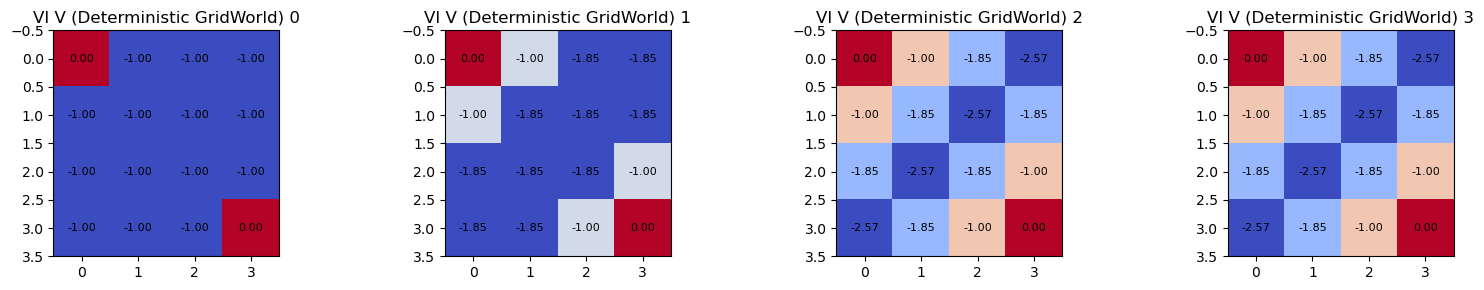

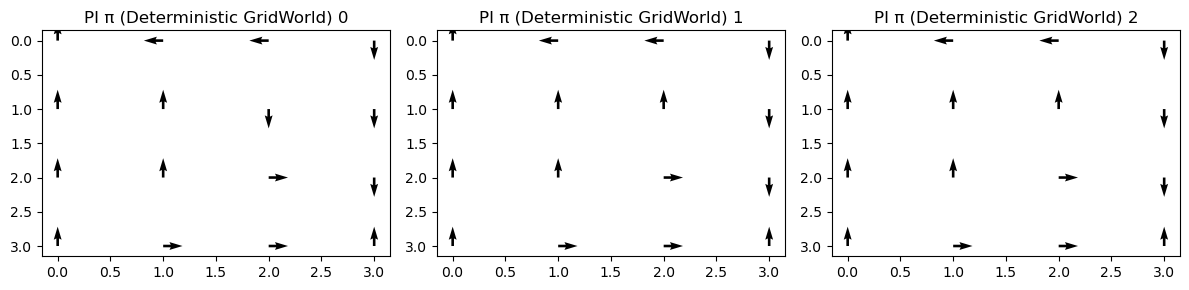

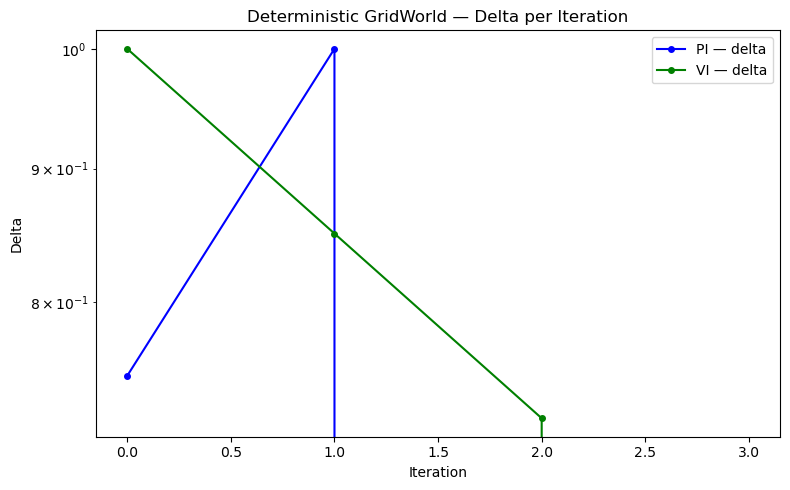

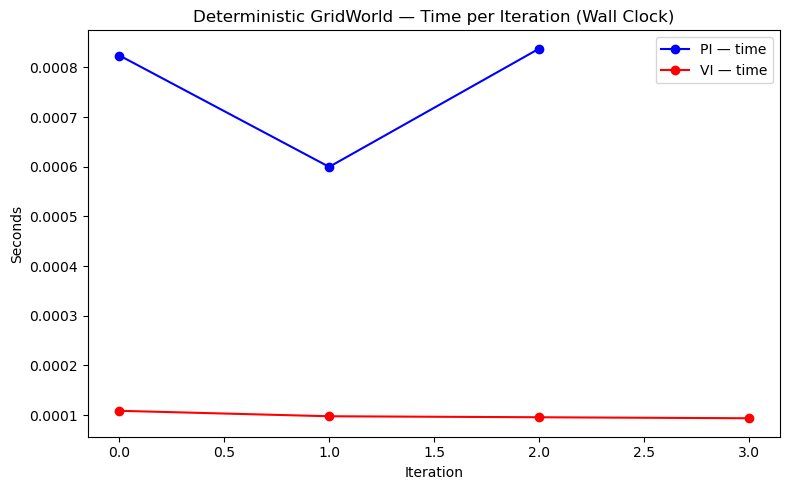


Stochastic GridWorld (slip=0.2)
G . . .
. . . .
. . . .
. . . G

Policy Iteration : 3 iterations  (0.0030s total)
Value  Iteration : 6 sweeps       (0.0016s total)


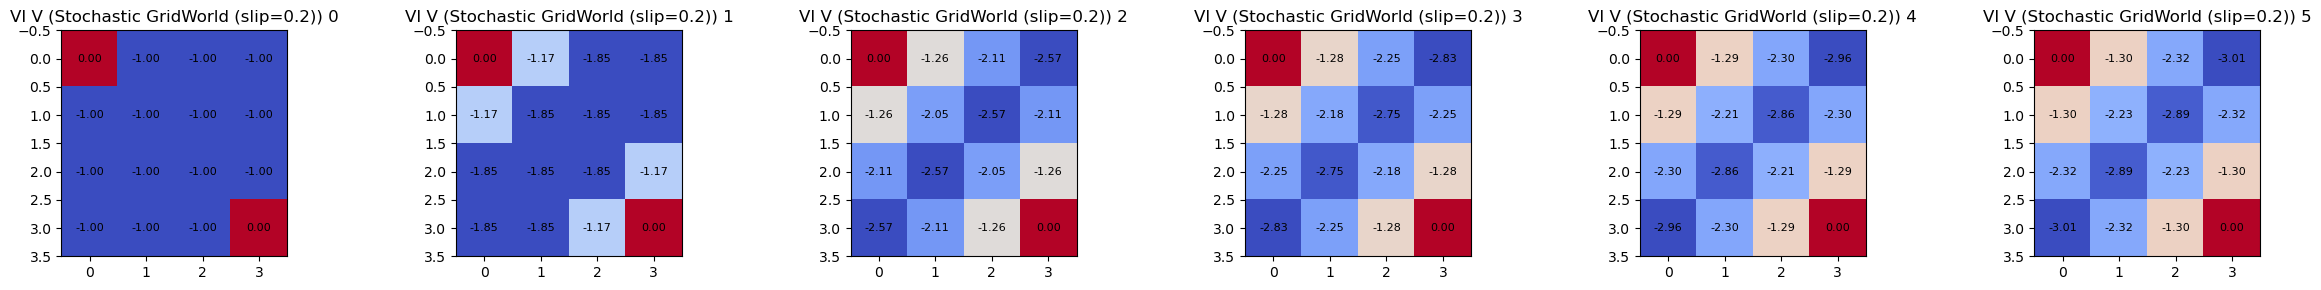

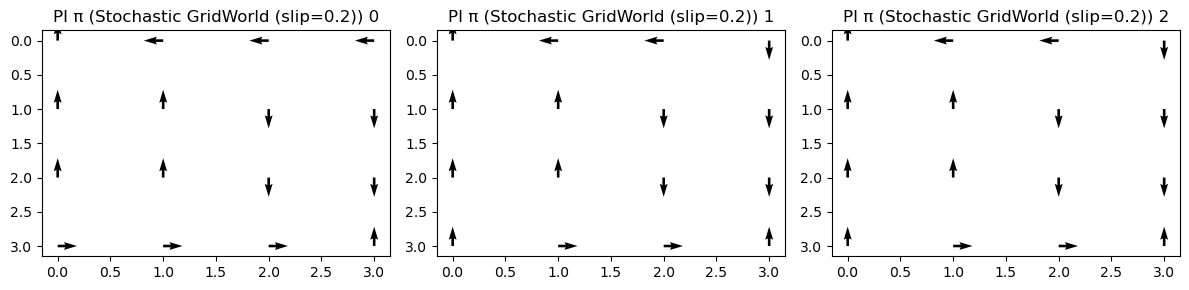

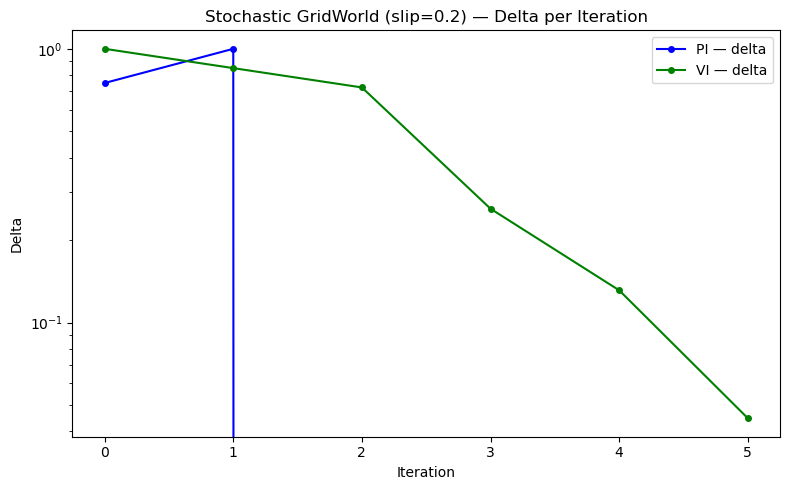

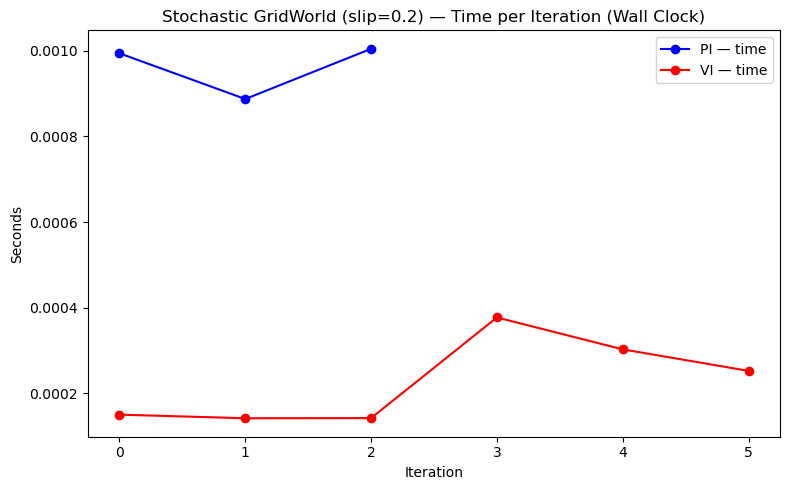

Gymnasium detected: FrozenLake adapter ready.


In [30]:
# =============================
# MAIN
# =============================
det_env = MazeEnv(rows=4, cols=4, goal_states=[0, 15],
                  step_cost=-1.0, slip_prob=0.0)
sto_env = MazeEnv(rows=4, cols=4, goal_states=[0, 15],
                  step_cost=-1.0, slip_prob=0.2)

pi_det, vi_det = benchmark(det_env, 'Deterministic GridWorld')
pi_sto, vi_sto = benchmark(sto_env, 'Stochastic GridWorld (slip=0.2)')


# =============================
# FROZENLAKE ADAPTER
# =============================
try:
    import gymnasium as gym

    def solve_frozenlake(env_name='FrozenLake-v1', is_slippery=True,
                         map_name='4x4', gamma=0.85, tol=5e-2):
        env = gym.make(env_name, is_slippery=is_slippery, map_name=map_name)
        P   = env.unwrapped.P
        nS  = env.observation_space.n
        nA  = env.action_space.n

        vi = run_value_iteration(P, nS, nA, gamma=gamma, tol=tol)
        pi = run_policy_iteration(P, nS, nA, gamma=gamma)

        return dict(value_iteration=vi, policy_iteration=pi)

    print('Gymnasium detected: FrozenLake adapter ready.')
except Exception:
    print('Gymnasium not available; FrozenLake experiments skipped.')